# Part D - Individual Questions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import palettable.wesanderson as wes

import sys
sys.path.insert(0 , './../MDS-UPDRS_Analysis/')
import distributions
from distributions import *
import seaborn as sns
import joblib

%load_ext autoreload
%autoreload 2

### Get Idiopathic ID's

In [3]:
meta = pd.read_csv('./../../data/01_raw/PPMI/PPMI_META_LINKAGE.csv')
idiopathic_ids = meta[np.logical_and(meta['Subgroup'] == 'Sporadic' , meta['CONCOHORT_DEFINITION'] == "Parkinson's Disease")]['PATNO'].unique()

### Specify Event IDs for which Genomic Data is Available

In [4]:
events = ['BL', 'V02' , 'V04' ,'V05',
          'V06' ,'V07' , 'V08' ,'V09' , 'V10' ,
          'V11' , 'V12' ,'V13' , 'V14' ,'V15' ,
          'V16' , 'V17' , 'V18','V19' ,'V20' ]

all_events = ['SC', 'BL', 'V01', 'V02', 'V03', 'V04', 'V05',
'V06', 'V07', 'V08', 'V09', 'V10', 'V11', 'V12',
'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19',
'ST', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25'
]

x_list = pd.DataFrame(np.arange(0 , 9.5 , 0.5) , index = events , columns=['response'])

## Section 1 - Pull in all relevant data

### MDS-UPDRS

#### Part 1

In [5]:
p1_1 = pd.read_csv('./../../data/01_raw/PPMI/Assesment_Exams/MDS-UPDRS_Part_I_21Jan2025.csv')
p1_1_filt = p1_1.loc[: , ['PATNO' , 'EVENT_ID'] + [col for col in p1_1.columns if 'NP1' in col]]

p1_2 = pd.read_csv('./../../data/01_raw/PPMI/Assesment_Exams/MDS-UPDRS_Part_I_Patient_Questionnaire_21Jan2025.csv')
p1_2_filt = p1_2.loc[: , ['PATNO' , 'EVENT_ID'] + [col for col in p1_2.columns if 'NP1' in col]]

p1_final = pd.merge(p1_1_filt , p1_2_filt , on = ['PATNO' , 'EVENT_ID'])
p1_final['NP1TOT'] = p1_final['NP1RTOT'] + p1_final['NP1PTOT']
p1_final = p1_final.drop(['NP1RTOT' , 'NP1PTOT'] , axis=1)
p1_final = p1_final.replace(101, np.nan).drop_duplicates()

p1_final = p1_final[p1_final['PATNO'].isin(idiopathic_ids)]

In [6]:
all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(p1_final['PATNO'].unique())) , 'PATNO' : np.repeat(p1_final['PATNO'].unique() , len(events))})

p1_final = p1_final[p1_final['EVENT_ID'].isin(events)]
p1_impute = pd.merge(all_tmpt , p1_final , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
p1_impute['EVENT_ID'] = pd.Categorical(p1_impute['EVENT_ID'] , categories=events , ordered=True)

for patno in p1_impute['PATNO'].unique() : 
    row_na = False
    df = p1_impute[p1_impute['PATNO'] == patno].copy()
    df['Temp_ID'] = df['EVENT_ID'].cat.codes.values
    for i in range(1, len(df) - 1):
        if df.iloc[i].isnull().any():  # Check if NaN exists in the row
            prev_row = df.iloc[i - 1]
            next_row = df.iloc[i + 1]
    
            # Check if the previous and next rows are consecutive
            if row_na : 
                if next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])
            else :
                if (prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] 
                        and next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID']):
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[[i - 1, i + 1]].mean(numeric_only=True))
                elif prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i - 1])
                elif next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])

            row_na = True
        else : 
            row_na = False
    
    df = df.drop('Temp_ID', axis=1)

    p1_impute[p1_impute['PATNO'] == patno] = df.copy()

p1 = p1_impute[np.logical_and(p1_impute['PATNO'].isin(idiopathic_ids) , p1_impute['EVENT_ID'].isin(events))]

#### Part 2

In [7]:
p2 = pd.read_csv('./../../data/01_raw/PPMI/Assesment_Exams/MDS_UPDRS_Part_II__Patient_Questionnaire_21Jan2025.csv')
p2_final = p2.loc[: , ['PATNO' , 'EVENT_ID'] + [col for col in p2.columns if 'NP2' in col]]
p2_final = p2_final.replace(101, np.nan).drop_duplicates()

p2_final = p2_final[p2_final['PATNO'].isin(idiopathic_ids)]

In [8]:
all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(p2_final['PATNO'].unique())) , 'PATNO' : np.repeat(p2_final['PATNO'].unique() , len(events))})

p2_final = p2_final[p2_final['EVENT_ID'].isin(events)]
p2_impute = pd.merge(all_tmpt , p2_final , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
p2_impute['EVENT_ID'] = pd.Categorical(p2_impute['EVENT_ID'] , categories=events , ordered=True)

for patno in p2_impute['PATNO'].unique() : 
    row_na = False
    df = p2_impute[p2_impute['PATNO'] == patno].copy()
    df['Temp_ID'] = df['EVENT_ID'].cat.codes.values
    for i in range(1, len(df) - 1):
        if df.iloc[i].isnull().any():  # Check if NaN exists in the row
            prev_row = df.iloc[i - 1]
            next_row = df.iloc[i + 1]
    
            # Check if the previous and next rows are consecutive
            if row_na : 
                if next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])
            else :
                if (prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] 
                        and next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID']):
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[[i - 1, i + 1]].mean(numeric_only=True))
                elif prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i - 1])
                elif next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])

            row_na = True
        else : 
            row_na = False
    
    df = df.drop('Temp_ID', axis=1)

    p2_impute[p2_impute['PATNO'] == patno] = df.copy()

p2 = p2_impute[np.logical_and(p2_impute['PATNO'].isin(idiopathic_ids) , p2_impute['EVENT_ID'].isin(events))]

#### Part 3

In [9]:
p3 = pd.read_csv('./../../data/01_raw/PPMI/Assesment_Exams/MDS-UPDRS_Part_III_21Jan2025.csv')
p3 = p3[p3['PDSTATE'].isin([np.nan , 'OFF'])]
p3_final = p3.loc[: , ['PATNO' , 'EVENT_ID' ,'NHY'] + [col for col in p3.columns if 'NP3' in col]]
p3_final = p3_final.replace(101, np.nan).drop_duplicates()

p3_final = p3_final[p3_final['PATNO'].isin(idiopathic_ids)]

p3_meta = p3.loc[ : , ['PATNO' , 'EVENT_ID' , 'PDTRTMNT' , 'PDSTATE' , 'HRPOSTMED' , 'HRDBSON', 'HRDBSOFF', 'PDMEDYN', 'DBSYN', 'ONOFFORDER', 'OFFEXAM', 'OFFNORSN', 'DBSOFFTM', 'ONEXAM', 'ONNORSN' ]]

In [10]:
all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(p3_final['PATNO'].unique())) , 'PATNO' : np.repeat(p3_final['PATNO'].unique() , len(events))})

p3_final = p3_final[p3_final['EVENT_ID'].isin(events)]
p3_impute = pd.merge(all_tmpt , p3_final , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
p3_impute['EVENT_ID'] = pd.Categorical(p3_impute['EVENT_ID'] , categories=events , ordered=True)

for patno in p3_impute['PATNO'].unique() : 
    row_na = False
    df = p3_impute[p3_impute['PATNO'] == patno].copy()
    df['Temp_ID'] = df['EVENT_ID'].cat.codes.values
    for i in range(1, len(df) - 1):
        if df.iloc[i].isnull().any():  # Check if NaN exists in the row
            prev_row = df.iloc[i - 1]
            next_row = df.iloc[i + 1]
    
            # Check if the previous and next rows are consecutive
            if row_na : 
                if next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])
            else :
                if (prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] 
                        and next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID']):
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[[i - 1, i + 1]].mean(numeric_only=True))
                elif prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i - 1])
                elif next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])

            row_na = True
        else : 
            row_na = False
    
    df = df.drop('Temp_ID', axis=1)

    p3_impute[p3_impute['PATNO'] == patno] = df.copy()

p3 = p3_impute[np.logical_and(p3_impute['PATNO'].isin(idiopathic_ids) , p3_impute['EVENT_ID'].isin(events))]

# Factor Analysis

In [14]:
p3.iloc[: , 2:-1].columns

Index(['NHY', 'NP3SPCH', 'NP3FACXP', 'NP3RIGN', 'NP3RIGRU', 'NP3RIGLU',
       'NP3RIGRL', 'NP3RIGLL', 'NP3FTAPR', 'NP3FTAPL', 'NP3HMOVR', 'NP3HMOVL',
       'NP3PRSPR', 'NP3PRSPL', 'NP3TTAPR', 'NP3TTAPL', 'NP3LGAGR', 'NP3LGAGL',
       'NP3RISNG', 'NP3GAIT', 'NP3FRZGT', 'NP3PSTBL', 'NP3POSTR', 'NP3BRADY',
       'NP3PTRMR', 'NP3PTRML', 'NP3KTRMR', 'NP3KTRML', 'NP3RTARU', 'NP3RTALU',
       'NP3RTARL', 'NP3RTALL', 'NP3RTALJ', 'NP3RTCON'],
      dtype='object')

Eigenvalues: [8.93209804 3.66787825 3.05888484 1.86493229 1.75128018 1.42808235
 1.19572812 0.94125709 0.83279801 0.82347862 0.75439732 0.69391764
 0.64225495 0.61804304 0.57530844 0.52359898 0.50348259 0.47428033
 0.45809862 0.44030082 0.41217131 0.38758967 0.37500787 0.34301232
 0.32123191 0.31707671 0.29281555 0.25670452 0.22626052 0.21957543
 0.19066841 0.17103937 0.16502046 0.14172546]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


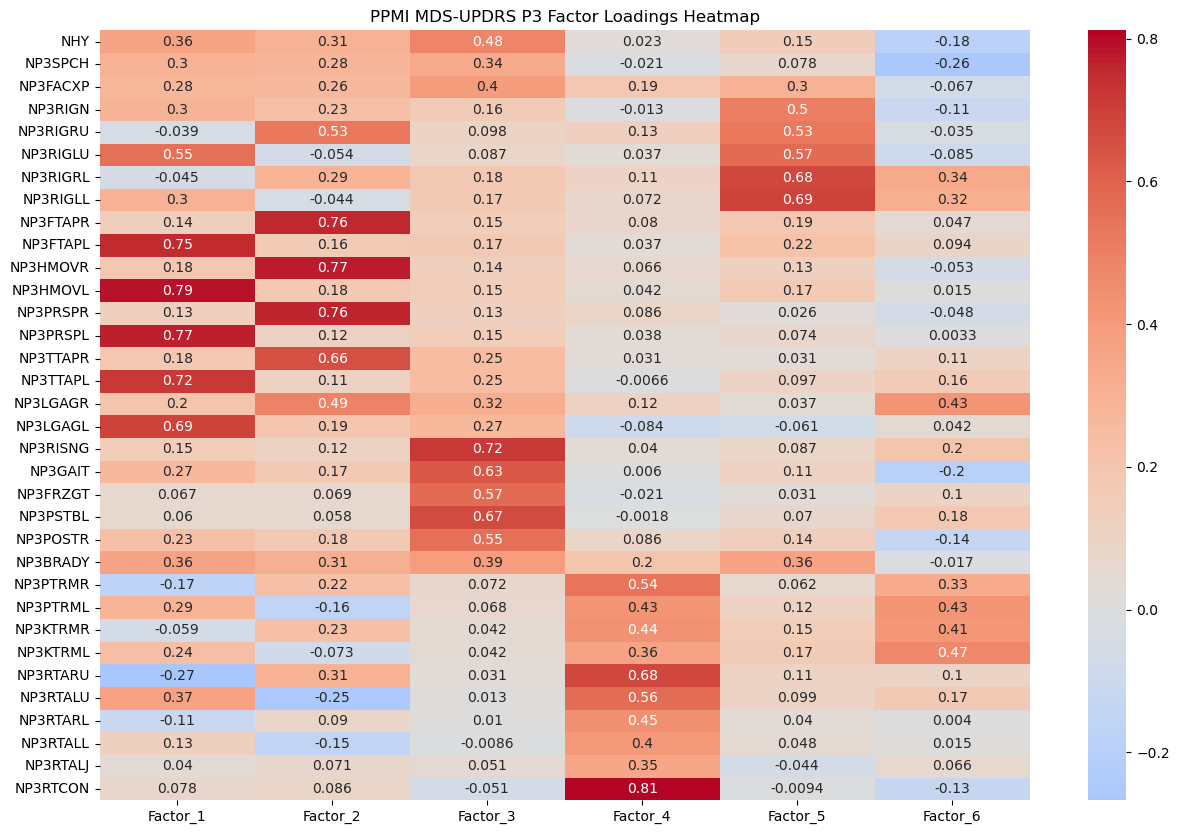

In [23]:
from factor_analyzer import FactorAnalyzer

objs = joblib.load("./../../data/03_final/PPMI_FA_model_P3ON.joblib")
fa = objs['fa']

# Fit the model
p3_cols = p3.iloc[: , 2:-1].columns

# Check Eigenvalues to determine how many factors to use
ev, v = fa.get_eigenvalues()
print("Eigenvalues:", ev)

factor_scores = fa.transform(p3.iloc[: , 2:-1].dropna())  # Transform the original data set
# Create a DataFrame from the scores
factor_scores_df = pd.DataFrame(factor_scores, columns=[f'Factor_{i+1}' for i in range(factor_scores.shape[1])]).add_prefix('MDS_UPDRS_P3_')

factor_scores_df['PATNO'] = p3.dropna(subset=p3_cols).reset_index(drop=True)['PATNO']
factor_scores_df['EVENT_ID'] = p3.dropna(subset=p3_cols).reset_index(drop=True)['EVENT_ID']
p3_FA = factor_scores_df

loadings = fa.loadings_
loading_df = pd.DataFrame(loadings, index=p3_cols, columns=[f'Factor_{i+1}' for i in range(loadings.shape[1])])

# Print loadings to see the result
plt.figure(figsize=(15, 10))
sns.heatmap(loading_df, annot=True, cmap='coolwarm', center=0)
plt.title('PPMI MDS-UPDRS P3 Factor Loadings Heatmap')
plt.savefig('./../Results/PPMI_P3_FA.png')
plt.show()

Eigenvalues: [5.72965824 1.40777261 1.05982888 0.83345358 0.67793814 0.61679234
 0.55787337 0.48836603 0.39991164 0.38388956 0.32203135 0.30016571
 0.22231856]


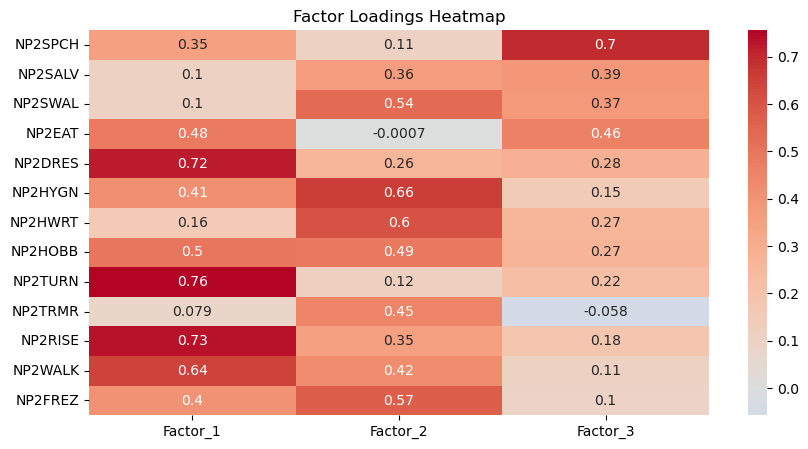

In [11]:
from factor_analyzer import FactorAnalyzer

objs = joblib.load("./../Tracking/fa_model_P2.joblib")
fa = objs['fa']

# Fit the model
p2_cols = p2.iloc[: , 2:-1].columns

# Check Eigenvalues to determine how many factors to use
ev, v = fa.get_eigenvalues()
print("Eigenvalues:", ev)

factor_scores = fa.transform(p2.iloc[: , 2:-1].dropna())  # Transform the original data set
# Create a DataFrame from the scores
factor_scores_df = pd.DataFrame(factor_scores, columns=[f'Factor_{i+1}' for i in range(factor_scores.shape[1])]).add_prefix('MDS_UPDRS_P2_')

factor_scores_df['PATNO'] = p2.dropna(subset=p2_cols).reset_index(drop=True)['PATNO']
factor_scores_df['EVENT_ID'] = p2.dropna(subset=p2_cols).reset_index(drop=True)['EVENT_ID']
p2_FA = factor_scores_df

loadings = fa.loadings_
loading_df = pd.DataFrame(loadings, index=p2_cols, columns=[f'Factor_{i+1}' for i in range(loadings.shape[1])])

# Print loadings to see the result
plt.figure(figsize=(10, 5))
sns.heatmap(loading_df, annot=True, cmap='coolwarm', center=0)
plt.title('Factor Loadings Heatmap')
plt.show()

Eigenvalues: [3.86119643 1.9317411  1.14881554 0.94688533 0.90148859 0.78508173
 0.72605029 0.61621036 0.52944114 0.48857386 0.41998899 0.38362404
 0.2609026 ]


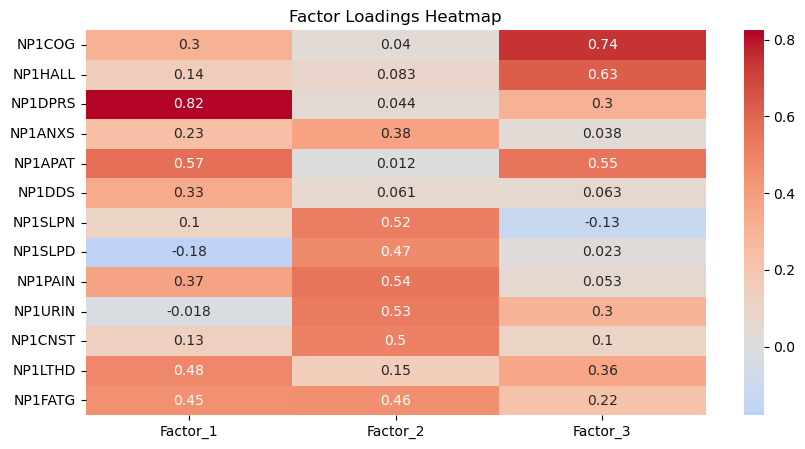

In [12]:
from factor_analyzer import FactorAnalyzer

objs = joblib.load("./../Tracking/fa_model_P1.joblib")
fa = objs['fa']

# Fit the model
p1_cols = p1.iloc[: , 2:-1].columns

# Check Eigenvalues to determine how many factors to use
ev, v = fa.get_eigenvalues()
print("Eigenvalues:", ev)

factor_scores = fa.transform(p1.iloc[: , 2:-1].dropna())  # Transform the original data set
# Create a DataFrame from the scores
factor_scores_df = pd.DataFrame(factor_scores, columns=[f'Factor_{i+1}' for i in range(factor_scores.shape[1])]).add_prefix('MDS_UPDRS_P1_')

factor_scores_df['PATNO'] = p1.dropna(subset=p1_cols).reset_index(drop=True)['PATNO']
factor_scores_df['EVENT_ID'] = p1.dropna(subset=p1_cols).reset_index(drop=True)['EVENT_ID']
p1_FA = factor_scores_df

loadings = fa.loadings_
loading_df = pd.DataFrame(loadings, index=p1_cols, columns=[f'Factor_{i+1}' for i in range(loadings.shape[1])])

# Print loadings to see the result
plt.figure(figsize=(10, 5))
sns.heatmap(loading_df, annot=True, cmap='coolwarm', center=0)
plt.title('Factor Loadings Heatmap')
plt.show()

In [13]:
tmp = pd.merge(p1_FA , p2_FA , on = ['PATNO' , 'EVENT_ID'])
final = pd.merge(tmp , p3_FA , on = ['PATNO' , 'EVENT_ID'])

In [14]:
final.to_csv('./FA_MDS-UPDRS_FROM_Tracking.csv')